### <b><font color='saddlebrown'>EDA датасета Google Play Store</font></b>

##### <b><font color='saddlebrown'>Описание данных</font></b>

- <i>App</i> - название приложения в Google Play Store
- <i>Category</i> - категория приложения
- <i>Rating</i> - средний пользовательский рейтинг приложения по шкале от 1 до 5.
- <i>Reviews</i> - количество пользовательских отзывов о приложении.
- <i>Size</i> - размер приложения
- <i>Installs</i> - количество установок приложения.
- <i>Type</i> - тип приложения: Free (бесплатное) или Paid (платное).
- <i>Price</i> - стоимость приложения в долларах США. Для бесплатных приложений значение равно 0.
- <i>Content Rating</i> - возрастное ограничение контента
- <i>Genres</i> - более детальная жанровая классификация приложения. Может содержать несколько жанров.
- <i>Last Updated</i> - дата последнего обновления приложения в магазине Google Play.
- <i>Current Ver</i> - текущая версия приложения.
- <i>Android Ver</i> - минимальная версия Android, необходимая для установки приложения.

##### <b><font color='saddlebrown'>Задача</font></b>
Провести EDA

In [1]:
# Импорт библиотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [56]:
googleplaystore = pd.read_csv('googleplaystore.csv')
googleplaystore.head(10)

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up
5,Paper flowers instructions,ART_AND_DESIGN,4.4,167,5.6M,"50,000+",Free,0,Everyone,Art & Design,"March 26, 2017",1.0,2.3 and up
6,Smoke Effect Photo Maker - Smoke Editor,ART_AND_DESIGN,3.8,178,19M,"50,000+",Free,0,Everyone,Art & Design,"April 26, 2018",1.1,4.0.3 and up
7,Infinite Painter,ART_AND_DESIGN,4.1,36815,29M,"1,000,000+",Free,0,Everyone,Art & Design,"June 14, 2018",6.1.61.1,4.2 and up
8,Garden Coloring Book,ART_AND_DESIGN,4.4,13791,33M,"1,000,000+",Free,0,Everyone,Art & Design,"September 20, 2017",2.9.2,3.0 and up
9,Kids Paint Free - Drawing Fun,ART_AND_DESIGN,4.7,121,3.1M,"10,000+",Free,0,Everyone,Art & Design;Creativity,"July 3, 2018",2.8,4.0.3 and up


In [47]:
googleplaystore.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  object 
 1   Category        10841 non-null  object 
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  object 
 4   Size            10841 non-null  object 
 5   Installs        10841 non-null  object 
 6   Type            10840 non-null  object 
 7   Price           10841 non-null  object 
 8   Content Rating  10840 non-null  object 
 9   Genres          10841 non-null  object 
 10  Last Updated    10841 non-null  object 
 11  Current Ver     10833 non-null  object 
 12  Android Ver     10838 non-null  object 
dtypes: float64(1), object(12)
memory usage: 1.1+ MB


In [48]:
googleplaystore.describe()

,Rating
count,9367.000000
mean,4.193338
std,0.537431
min,1.000000
25%,4.000000
50%,4.300000
75%,4.500000
max,19.000000


In [104]:
df_googleplay = googleplaystore.copy() # Создаем копию датафрейма для дальнейшей очистки и анализа
df_googleplay[df_googleplay['Reviews'].str.contains('M', na=False) == True] # Находим строку с некорректным значением в столбце Reviews (строка 10472) и удаляем ее
df_googleplay.drop(10472, inplace = True) # Удаляем строку с некорректным значением в столбце Reviews
df_googleplay['Reviews'] = df_googleplay['Reviews'].str.replace('null', '0').astype(int)   # Заменяем текст 'null' на '0' и преобразуем столбец Reviews в числовой тип данных
df_googleplay.info() 

<class 'pandas.core.frame.DataFrame'>
Index: 10840 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10840 non-null  object 
 1   Category        10840 non-null  object 
 2   Rating          9366 non-null   float64
 3   Reviews         10840 non-null  int64  
 4   Size            10840 non-null  object 
 5   Installs        10840 non-null  object 
 6   Type            10839 non-null  object 
 7   Price           10840 non-null  object 
 8   Content Rating  10840 non-null  object 
 9   Genres          10840 non-null  object 
 10  Last Updated    10840 non-null  object 
 11  Current Ver     10832 non-null  object 
 12  Android Ver     10838 non-null  object 
dtypes: float64(1), int64(1), object(11)
memory usage: 1.2+ MB


In [105]:
df_googleplay[(df_googleplay['Size'].str.contains('Varies with device', na=False) == True)]

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
37,Floor Plan Creator,ART_AND_DESIGN,4.1,36639,Varies with device,"5,000,000+",Free,0,Everyone,Art & Design,"July 14, 2018",Varies with device,2.3.3 and up
42,Textgram - write on photos,ART_AND_DESIGN,4.4,295221,Varies with device,"10,000,000+",Free,0,Everyone,Art & Design,"July 30, 2018",Varies with device,Varies with device
52,Used Cars and Trucks for Sale,AUTO_AND_VEHICLES,4.6,17057,Varies with device,"1,000,000+",Free,0,Everyone,Auto & Vehicles,"July 30, 2018",Varies with device,Varies with device
67,Ulysse Speedometer,AUTO_AND_VEHICLES,4.3,40211,Varies with device,"5,000,000+",Free,0,Everyone,Auto & Vehicles,"July 30, 2018",Varies with device,Varies with device
68,REPUVE,AUTO_AND_VEHICLES,3.9,356,Varies with device,"100,000+",Free,0,Everyone,Auto & Vehicles,"May 25, 2018",Varies with device,Varies with device
...,...,...,...,...,...,...,...,...,...,...,...,...,...
10713,My Earthquake Alerts - US & Worldwide Earthquakes,WEATHER,4.4,3471,Varies with device,"100,000+",Free,0,Everyone,Weather,"July 24, 2018",Varies with device,Varies with device
10725,Posta App,MAPS_AND_NAVIGATION,3.6,8,Varies with device,"1,000+",Free,0,Everyone,Maps & Navigation,"September 27, 2017",Varies with device,4.4 and up
10765,Chat For Strangers - Video Chat,SOCIAL,3.4,622,Varies with device,"100,000+",Free,0,Mature 17+,Social,"May 23, 2018",Varies with device,Varies with device
10826,Frim: get new friends on local chat rooms,SOCIAL,4.0,88486,Varies with device,"5,000,000+",Free,0,Mature 17+,Social,"March 23, 2018",Varies with device,Varies with device


In [106]:
M = 8829
k = 316
Varies_with_device = 1695
Total = M + k + Varies_with_device
print(Total)
df_googleplay[(df_googleplay['Size'].str.contains('M', na=False) == False) & (df_googleplay['Size'].str.contains('Varies with device', na=False) == False)]

10840


,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
58,Restart Navigator,AUTO_AND_VEHICLES,4.0,1403,201k,"100,000+",Free,0,Everyone,Auto & Vehicles,"August 26, 2014",1.0.1,2.2 and up
209,Plugin:AOT v5.0,BUSINESS,3.1,4034,23k,"100,000+",Free,0,Everyone,Business,"September 11, 2015",3.0.1.11 (Build 311),2.2 and up
384,Hangouts Dialer - Call Phones,COMMUNICATION,4.0,122498,79k,"10,000,000+",Free,0,Everyone,Communication,"September 2, 2015",0.1.100944346,4.0.3 and up
450,Caller ID +,COMMUNICATION,4.0,9498,118k,"1,000,000+",Free,0,Everyone,Communication,"June 7, 2016",5.28.0,2.3 and up
458,GO Notifier,COMMUNICATION,4.2,124346,695k,"10,000,000+",Free,0,Everyone,Communication,"July 6, 2014",2.8,2.0 and up
...,...,...,...,...,...,...,...,...,...,...,...,...,...
10763,FP Разбитый дисплей,FAMILY,4.5,922,552k,"50,000+",Free,0,Everyone,Entertainment,"September 20, 2014",1.1,1.6 and up
10764,FP Transportation,AUTO_AND_VEHICLES,NaN,1,885k,1+,Free,0,Everyone,Auto & Vehicles,"March 9, 2018",10.0.0,4.0 and up
10798,Word Search Tab 1 FR,FAMILY,NaN,0,1020k,50+,Paid,$1.04,Everyone,Puzzle,"February 6, 2012",1.1,3.0 and up
10832,FR Tides,WEATHER,3.8,1195,582k,"100,000+",Free,0,Everyone,Weather,"February 16, 2014",6.0,2.1 and up


In [107]:
df_googleplay['Size'] = df_googleplay['Size'].str.replace('Varies with device', '0k') 
df_googleplay[(df_googleplay['Size'] == '0k')]

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
37,Floor Plan Creator,ART_AND_DESIGN,4.1,36639,0k,"5,000,000+",Free,0,Everyone,Art & Design,"July 14, 2018",Varies with device,2.3.3 and up
42,Textgram - write on photos,ART_AND_DESIGN,4.4,295221,0k,"10,000,000+",Free,0,Everyone,Art & Design,"July 30, 2018",Varies with device,Varies with device
52,Used Cars and Trucks for Sale,AUTO_AND_VEHICLES,4.6,17057,0k,"1,000,000+",Free,0,Everyone,Auto & Vehicles,"July 30, 2018",Varies with device,Varies with device
67,Ulysse Speedometer,AUTO_AND_VEHICLES,4.3,40211,0k,"5,000,000+",Free,0,Everyone,Auto & Vehicles,"July 30, 2018",Varies with device,Varies with device
68,REPUVE,AUTO_AND_VEHICLES,3.9,356,0k,"100,000+",Free,0,Everyone,Auto & Vehicles,"May 25, 2018",Varies with device,Varies with device
...,...,...,...,...,...,...,...,...,...,...,...,...,...
10713,My Earthquake Alerts - US & Worldwide Earthquakes,WEATHER,4.4,3471,0k,"100,000+",Free,0,Everyone,Weather,"July 24, 2018",Varies with device,Varies with device
10725,Posta App,MAPS_AND_NAVIGATION,3.6,8,0k,"1,000+",Free,0,Everyone,Maps & Navigation,"September 27, 2017",Varies with device,4.4 and up
10765,Chat For Strangers - Video Chat,SOCIAL,3.4,622,0k,"100,000+",Free,0,Mature 17+,Social,"May 23, 2018",Varies with device,Varies with device
10826,Frim: get new friends on local chat rooms,SOCIAL,4.0,88486,0k,"5,000,000+",Free,0,Mature 17+,Social,"March 23, 2018",Varies with device,Varies with device


In [108]:
df_googleplay['Size_Measur'] = df_googleplay['Size'].str[-1]
df_googleplay['Size'] = df_googleplay['Size'].str[:-1]
df_googleplay['Size'] = df_googleplay['Size'].astype(float)
df_googleplay

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Size_Measur
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19.0,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up,M
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14.0,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up,M
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up,M
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25.0,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up,M
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up,M
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10836,Sya9a Maroc - FR,FAMILY,4.5,38,53.0,"5,000+",Free,0,Everyone,Education,"July 25, 2017",1.48,4.1 and up,M
10837,Fr. Mike Schmitz Audio Teachings,FAMILY,5.0,4,3.6,100+,Free,0,Everyone,Education,"July 6, 2018",1.0,4.1 and up,M
10838,Parkinson Exercices FR,MEDICAL,NaN,3,9.5,"1,000+",Free,0,Everyone,Medical,"January 20, 2017",1.0,2.2 and up,M
10839,The SCP Foundation DB fr nn5n,BOOKS_AND_REFERENCE,4.5,114,0.0,"1,000+",Free,0,Mature 17+,Books & Reference,"January 19, 2015",Varies with device,Varies with device,k


In [109]:
for index, row in df_googleplay.iterrows():
    if row['Size_Measur'] == 'M':
        df_googleplay.at[index, 'Size'] = row['Size'] * 1024
    elif row['Size_Measur'] == 'k':
        df_googleplay.at[index, 'Size'] = row['Size']
    elif row['Size_Measur'] == '0':
        df_googleplay.at[index, 'Size'] = 0
df_googleplay

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Size_Measur
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19456.0,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up,M
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14336.0,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up,M
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8908.8,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up,M
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25600.0,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up,M
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2867.2,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up,M
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10836,Sya9a Maroc - FR,FAMILY,4.5,38,54272.0,"5,000+",Free,0,Everyone,Education,"July 25, 2017",1.48,4.1 and up,M
10837,Fr. Mike Schmitz Audio Teachings,FAMILY,5.0,4,3686.4,100+,Free,0,Everyone,Education,"July 6, 2018",1.0,4.1 and up,M
10838,Parkinson Exercices FR,MEDICAL,NaN,3,9728.0,"1,000+",Free,0,Everyone,Medical,"January 20, 2017",1.0,2.2 and up,M
10839,The SCP Foundation DB fr nn5n,BOOKS_AND_REFERENCE,4.5,114,0.0,"1,000+",Free,0,Mature 17+,Books & Reference,"January 19, 2015",Varies with device,Varies with device,k


In [115]:
df_googleplay.head(50)

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Size_Measur
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19456.0,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up,M
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14336.0,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up,M
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8908.8,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up,M
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25600.0,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up,M
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2867.2,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up,M
5,Paper flowers instructions,ART_AND_DESIGN,4.4,167,5734.4,"50,000+",Free,0,Everyone,Art & Design,"March 26, 2017",1.0,2.3 and up,M
6,Smoke Effect Photo Maker - Smoke Editor,ART_AND_DESIGN,3.8,178,19456.0,"50,000+",Free,0,Everyone,Art & Design,"April 26, 2018",1.1,4.0.3 and up,M
7,Infinite Painter,ART_AND_DESIGN,4.1,36815,29696.0,"1,000,000+",Free,0,Everyone,Art & Design,"June 14, 2018",6.1.61.1,4.2 and up,M
8,Garden Coloring Book,ART_AND_DESIGN,4.4,13791,33792.0,"1,000,000+",Free,0,Everyone,Art & Design,"September 20, 2017",2.9.2,3.0 and up,M
9,Kids Paint Free - Drawing Fun,ART_AND_DESIGN,4.7,121,3174.4,"10,000+",Free,0,Everyone,Art & Design;Creativity,"July 3, 2018",2.8,4.0.3 and up,M


In [116]:

df_googleplay.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10840 entries, 0 to 10840
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10840 non-null  object 
 1   Category        10840 non-null  object 
 2   Rating          9366 non-null   float64
 3   Reviews         10840 non-null  int64  
 4   Size            10840 non-null  float64
 5   Installs        10840 non-null  object 
 6   Type            10839 non-null  object 
 7   Price           10840 non-null  object 
 8   Content Rating  10840 non-null  object 
 9   Genres          10840 non-null  object 
 10  Last Updated    10840 non-null  object 
 11  Current Ver     10832 non-null  object 
 12  Android Ver     10838 non-null  object 
 13  Size_Measur     10840 non-null  object 
dtypes: float64(2), int64(1), object(11)
memory usage: 1.5+ MB


## EDA по чек-листу 1-в-1
Ниже идет новый структурированный блок строго по этапам чек-листа: 1 -> 14.

In [31]:
# 1. Загрузка данных
check_df = pd.read_csv('googleplaystore.csv')
print('Shape:', check_df.shape)
display(check_df.head(3))

Shape: (10841, 13)


,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up


In [32]:
# 2. Добавление новых столбцов на основе имеющихся
check_df['Reviews_log'] = np.log1p(pd.to_numeric(check_df['Reviews'], errors='coerce'))
check_df['Installs_num'] = pd.to_numeric(check_df['Installs'].astype(str).str.replace(r'[+,]', '', regex=True), errors='coerce')
check_df['Installs_log'] = np.log1p(check_df['Installs_num'])
print(check_df[['Reviews_log', 'Installs_num', 'Installs_log']].head())

   Reviews_log  Installs_num  Installs_log
0     5.075174       10000.0      9.210440
1     6.875232      500000.0     13.122365
2    11.379520     5000000.0     15.424949
3    12.281389    50000000.0     17.727534
4     6.875232      100000.0     11.512935


In [39]:
# 3. Парсинг столбцов
check_df['Rating'] = pd.to_numeric(check_df['Rating'], errors='coerce')
check_df['Reviews'] = pd.to_numeric(check_df['Reviews'], errors='coerce')
check_df['Price'] = pd.to_numeric(check_df['Price'].astype(str).str.replace('$', '', regex=False), errors='coerce')
check_df['Last Updated'] = pd.to_datetime(check_df['Last Updated'], errors='coerce')

# Парсинг размера в MB
size_str_check = check_df['Size'].astype(str).str.strip()
size_num_check = pd.to_numeric(size_str_check.str.replace(r'[^0-9.]', '', regex=True), errors='coerce')
size_unit_check = size_str_check.str.extract(r'([kM])', expand=False)
check_df['Size_MB'] = np.where(size_unit_check == 'k', size_num_check / 1024, size_num_check)
check_df.loc[size_str_check.str.contains('Varies with device', case=False, na=False), 'Size_MB'] = np.nan

print(check_df[['Rating', 'Reviews', 'Price', 'Last Updated', 'Size_MB']].dtypes)

Rating                 float64
Reviews                float64
Price                  float64
Last Updated    datetime64[ns]
Size_MB                float64
dtype: object


In [34]:
# 4. Удаление столбцов
# Удаляем исходный текстовый Installs, потому что уже есть числовой Installs_num.
check_df = check_df.drop(columns=['Installs'])
print('Столбцы после удаления Installs:')
print(check_df.columns.tolist()[:10], '...')

Столбцы после удаления Installs:
['App', 'Category', 'Rating', 'Reviews', 'Size', 'Type', 'Price', 'Content Rating', 'Genres', 'Last Updated'] ...


In [35]:
# 5. Работа с дубликатами
dup_count = check_df.duplicated().sum()
check_df = check_df.drop_duplicates().copy()
print('Найдено дубликатов:', dup_count)
print('Размер после удаления дубликатов:', check_df.shape)

Найдено дубликатов: 483
Размер после удаления дубликатов: (10358, 15)


In [36]:
# 6. Унификация категорий и единиц измерения
check_df['Type'] = check_df['Type'].astype(str).str.strip().str.title()
check_df['Content Rating'] = check_df['Content Rating'].astype(str).str.strip()
check_df['Category'] = check_df['Category'].astype(str).str.strip().str.upper()
print('Уникальные Type:', check_df['Type'].unique()[:5])

Уникальные Type: ['Free' 'Paid' 'Nan' '0']


In [37]:
# 7. Работа с не типичными значениями (нули, отрицательные, некорректные)
invalid_rating = (~check_df['Rating'].between(1, 5, inclusive='both')).sum()
invalid_price = (check_df['Price'] < 0).sum()
strange_category = check_df['Category'].str.match(r'^\d+(\.\d+)?$', na=False).sum()

check_df = check_df[check_df['Rating'].between(1, 5, inclusive='both')]
check_df = check_df[check_df['Price'].fillna(0) >= 0]
check_df = check_df[~check_df['Category'].str.match(r'^\d+(\.\d+)?$', na=False)]

print('Было аномалий Rating:', invalid_rating)
print('Было отрицательных Price:', invalid_price)
print('Было числовых Category:', strange_category)
print('Размер после чистки нетипичных значений:', check_df.shape)

Было аномалий Rating: 1466
Было отрицательных Price: 0
Было числовых Category: 1
Размер после чистки нетипичных значений: (8892, 15)


In [40]:
# 8. Работа с отсутствующими значениями
check_df['Type'] = check_df['Type'].replace({'Nan': np.nan})
check_df['Content Rating'] = check_df['Content Rating'].replace({'Nan': np.nan})
check_df['Type'] = check_df['Type'].fillna('Unknown')
check_df['Content Rating'] = check_df['Content Rating'].fillna('Unknown')
check_df['Size_MB'] = check_df.groupby('Category', observed=True)['Size_MB'].transform(lambda s: s.fillna(s.median()))

print('Остаток пропусков в ключевых столбцах:')
print(check_df[['Rating', 'Reviews', 'Price', 'Size_MB', 'Type', 'Content Rating']].isna().sum())

Остаток пропусков в ключевых столбцах:
Rating            0
Reviews           0
Price             0
Size_MB           0
Type              0
Content Rating    0
dtype: int64


In [41]:
# 9. Одномерный анализ числовых столбцов
num_cols_check = ['Rating', 'Reviews', 'Installs_num', 'Price', 'Size_MB']
print(check_df[num_cols_check].describe().T)

               count          mean           std       min        25%  \
Rating        8892.0  4.187877e+00  5.223767e-01  1.000000      4.000   
Reviews       8892.0  4.727764e+05  2.905052e+06  1.000000    164.000   
Installs_num  8892.0  1.648965e+07  8.637600e+07  1.000000  10000.000   
Price         8892.0  9.631545e-01  1.618934e+01  0.000000      0.000   
Size_MB       8892.0  2.133142e+01  2.200125e+01  0.008301      5.975   

                   50%         75%           max  
Rating             4.3        4.50  5.000000e+00  
Reviews         4714.5    71266.75  7.815831e+07  
Installs_num  500000.0  5000000.00  1.000000e+09  
Price              0.0        0.00  4.000000e+02  
Size_MB           13.0       29.00  1.000000e+02  


In [42]:
# 10. Одномерный анализ категориальных столбцов
print('Category top-10:')
print(check_df['Category'].value_counts().head(10))
print('\nType:')
print(check_df['Type'].value_counts())
print('\nContent Rating:')
print(check_df['Content Rating'].value_counts())

Category top-10:
Category
FAMILY             1718
GAME               1074
TOOLS               734
PRODUCTIVITY        334
FINANCE             317
PERSONALIZATION     310
COMMUNICATION       307
LIFESTYLE           305
PHOTOGRAPHY         304
MEDICAL             302
Name: count, dtype: int64

Type:
Type
Free    8279
Paid     613
Name: count, dtype: int64

Content Rating:
Content Rating
Everyone           7095
Teen               1022
Mature 17+          411
Everyone 10+        360
Adults only 18+       3
Unrated               1
Name: count, dtype: int64


In [43]:
# 11. Работа с выбросами
q1 = check_df['Reviews_log'].quantile(0.25)
q3 = check_df['Reviews_log'].quantile(0.75)
iqr = q3 - q1
low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
check_df = check_df[check_df['Reviews_log'].between(low, high, inclusive='both')].copy()
print('Размер после фильтра выбросов по Reviews_log:', check_df.shape)

Размер после фильтра выбросов по Reviews_log: (8892, 16)


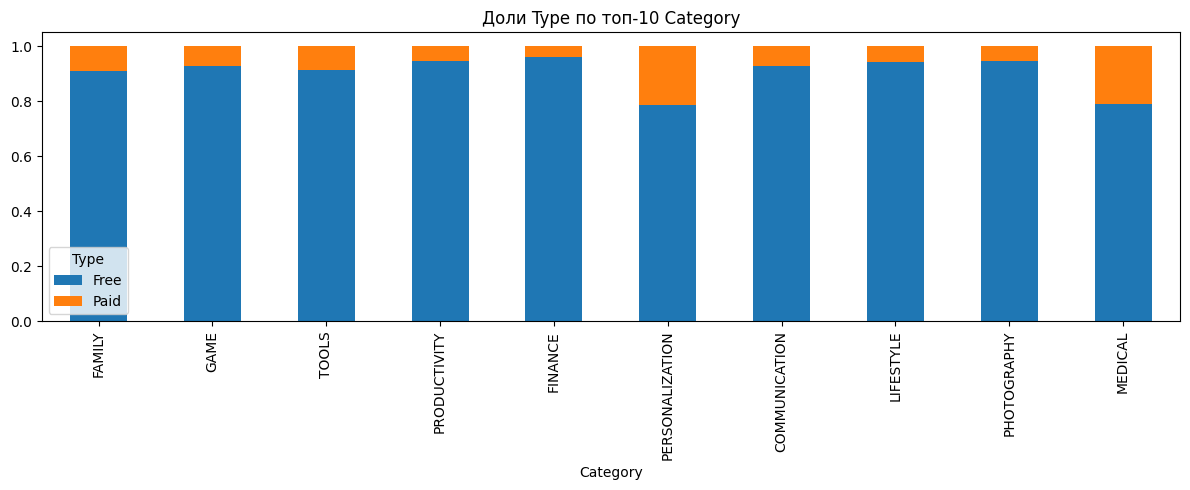

In [44]:
# 12. Двумерный анализ категориальных столбцов
cat2 = pd.crosstab(check_df['Category'], check_df['Type'])
cat2_top = cat2.sum(axis=1).sort_values(ascending=False).head(10).index
cat2_share = cat2.loc[cat2_top].div(cat2.loc[cat2_top].sum(axis=1), axis=0)
cat2_share.plot(kind='bar', stacked=True, figsize=(12, 5))
plt.title('Доли Type по топ-10 Category')
plt.tight_layout()
plt.show()

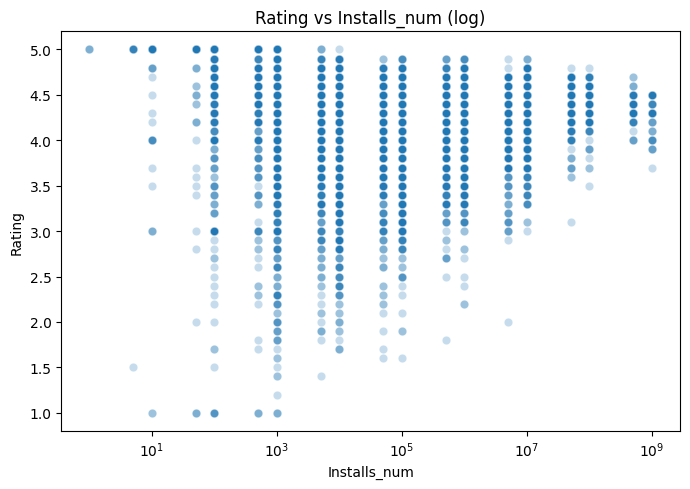

In [45]:
# 13. Двумерный анализ числовых столбцов
plt.figure(figsize=(7, 5))
sns.scatterplot(data=check_df, x='Installs_num', y='Rating', alpha=0.25)
plt.xscale('log')
plt.title('Rating vs Installs_num (log)')
plt.tight_layout()
plt.show()

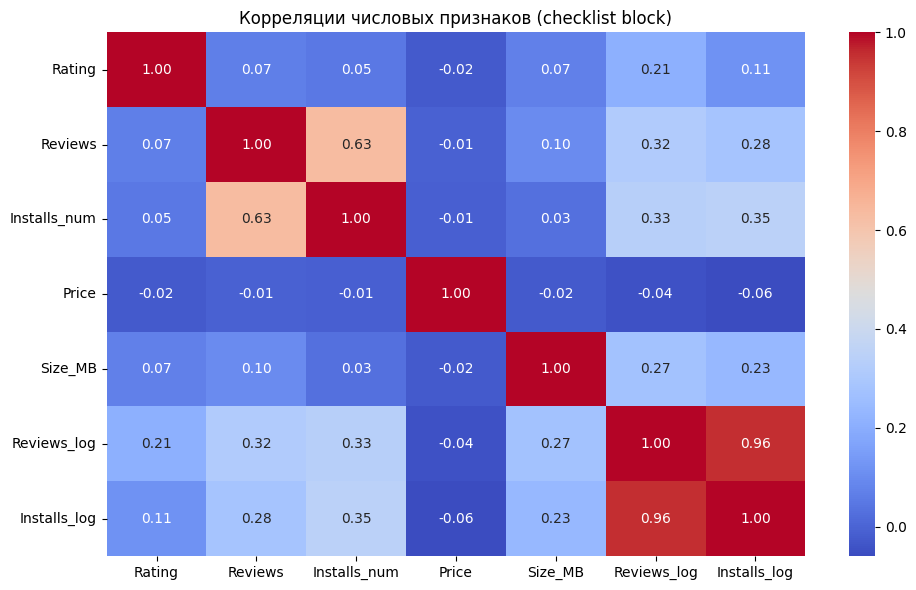

In [46]:
# 14. Многомерный анализ
corr_cols = ['Rating', 'Reviews', 'Installs_num', 'Price', 'Size_MB', 'Reviews_log', 'Installs_log']
plt.figure(figsize=(10, 6))
sns.heatmap(check_df[corr_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Корреляции числовых признаков (checklist block)')
plt.tight_layout()
plt.show()